In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pathlib as pl
import numpy as np

In [2]:
experiments = {path.name: pd.read_csv(path/"data.csv") for path in pl.Path().glob(pattern='without_abs_bug_fixed_units*') if path.is_dir()}

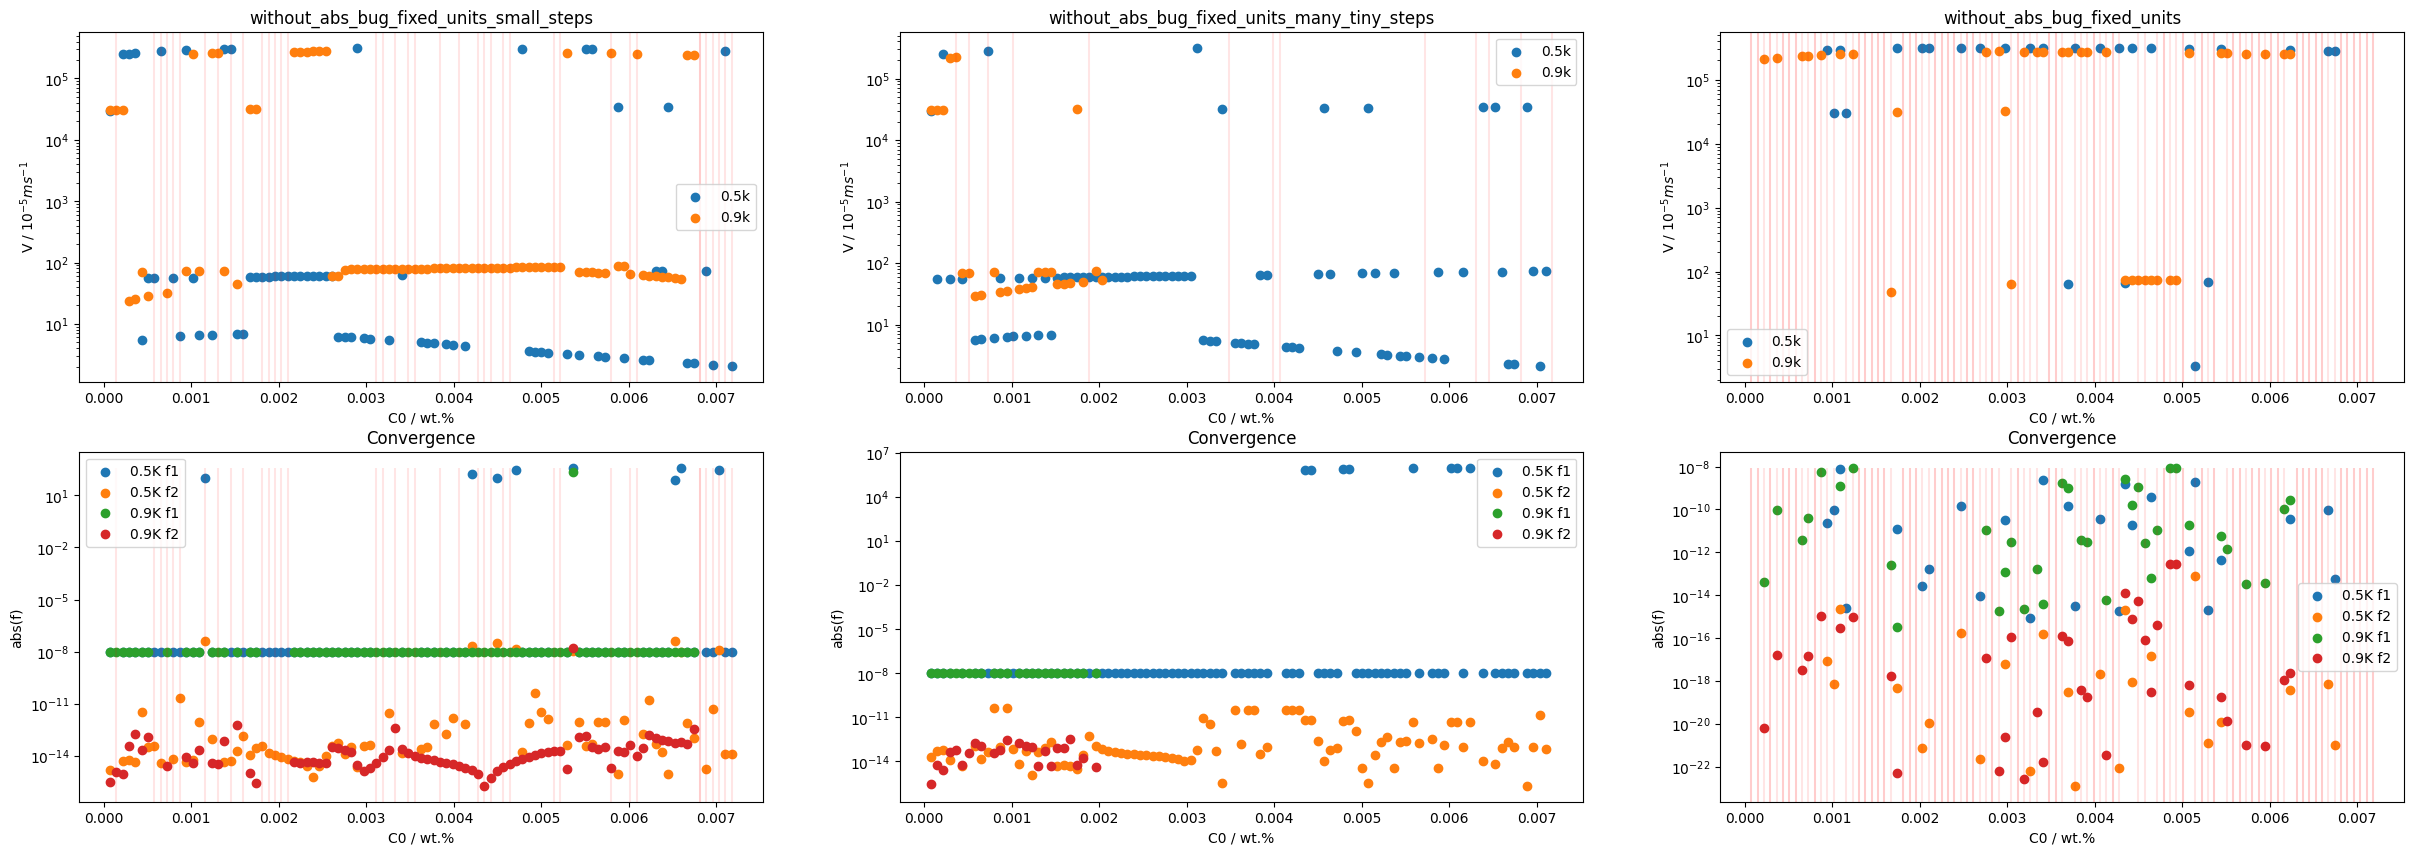

In [3]:
fig, axes = plt.subplots(nrows=2, ncols=len(experiments), figsize=(30,10))
for i, (name, data) in enumerate(experiments.items()):
	axes[0, i].set_title(name)
	axes[1, i].set_title("Convergence")
	for dT in data['dT'].unique():
		subset = data[data['dT']==dT]
		converged = data[(data['dT']==dT) & (data['diverged']==False)]
		# V plots
		axes[0, i].scatter(converged['C0'], converged['V']*1e5, label=f'{dT}k')
		axes[0, i].set_yscale('log')
		# axes[0, i].set_ylim(-1, 100)
		axes[0, i].vlines(subset['C0'][subset['diverged']], ymin=-1e100, ymax=1e100, colors='red', alpha=0.1)
		axes[0, i].legend()
		axes[0, i].set_xlabel('C0 / wt.%')
		axes[0, i].set_ylabel('V / $10^{-5} ms^{-1} $')

		# Convergence plots
		axes[1, i].scatter(subset['C0'], subset['f1'].abs(), label=f'{dT}K f1')
		axes[1, i].scatter(subset['C0'], subset['f2'].abs(), label=f'{dT}K f2')
		all_fs = np.hstack([data['f1'].abs(), data['f2'].abs()])
		axes[1, i].vlines(subset['C0'][subset['diverged']], ymin=all_fs.min(), ymax=all_fs.max(), colors='red', alpha=0.1)
		axes[1, i].set_yscale('log')
		axes[1, i].legend()
		axes[1, i].set_xlabel('C0 / wt.%')
		axes[1, i].set_ylabel('abs(f)')
pass